In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('dataset.csv')
print(df.shape)
print(df.head())
print(df['track_genre'].value_counts())


(114000, 21)
   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          57       210826 

In [6]:
# Alle Genres anzeigen
print(df['track_genre'].unique())

<StringArray>
[   'acoustic',    'afrobeat',    'alt-rock', 'alternative',     'ambient',
       'anime', 'black-metal',   'bluegrass',       'blues',      'brazil',
 ...
     'spanish',       'study',     'swedish',   'synth-pop',       'tango',
      'techno',      'trance',    'trip-hop',     'turkish', 'world-music']
Length: 114, dtype: str


In [18]:
# Nach unseren Genres suchen
genres_check = ['afrobeat', 'r-n-b', 'jazz', 'blues', 'indie', 
                'soul', 'hip-hop', 'reggae', 'latin', 'gospel']

for genre in genres_check:
    if genre in df['track_genre'].values:
        print(f" {genre} - gefunden!")
    else:
        print(f" {genre} - nicht gefunden")

 afrobeat - gefunden!
 r-n-b - gefunden!
 jazz - gefunden!
 blues - gefunden!
 indie - gefunden!
 soul - gefunden!
 hip-hop - gefunden!
 reggae - gefunden!
 latin - gefunden!
 gospel - gefunden!


In [19]:
# Genres für unser Projekt auswählen
african = ['afrobeat']
western_black = ['r-n-b', 'blues', 'jazz', 'soul', 'hip-hop', 'reggae']


alle_genres = african + western_black 

# Filtern
df_projekt = df[df['track_genre'].isin(alle_genres)]
print(df_projekt.shape)
print(df_projekt['track_genre'].value_counts())

(7000, 21)
track_genre
afrobeat    1000
blues       1000
hip-hop     1000
jazz        1000
r-n-b       1000
reggae      1000
soul        1000
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_21196\1960959437.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_dance.index, y=genre_dance.values, palette='viridis')


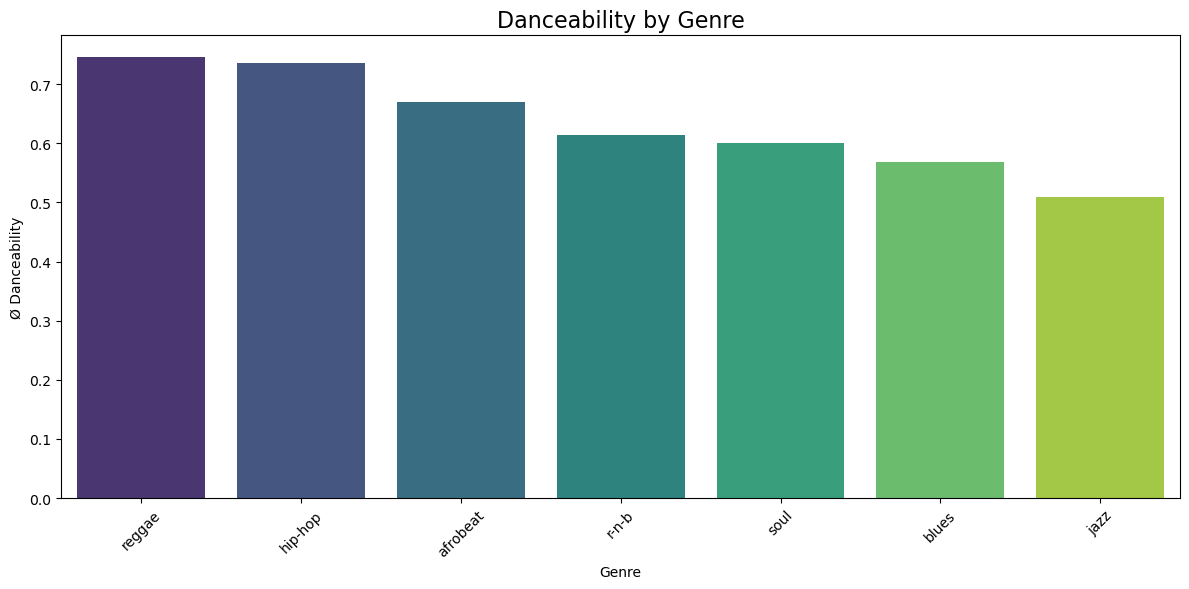

In [9]:
# Gruppe hinzufügen
df_projekt = df_projekt.copy()
df_projekt['gruppe'] = df_projekt['track_genre'].apply(
    lambda x: ' African' if x == 'afrobeat' else ' Western Black'
)

# Analyse 1: Tanzbarkeit- Welches Genre ist am tanzbarsten?
plt.figure(figsize=(12, 6))
genre_dance = df_projekt.groupby('track_genre')['danceability'].mean().sort_values(ascending=False)
sns.barplot(x=genre_dance.index, y=genre_dance.values, palette='viridis')
plt.title('Danceability by Genre', fontsize=16)
plt.xlabel('Genre')
plt.ylabel('Ø Danceability')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_21196\3219060687.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_dance.index, y=genre_dance.values, palette='viridis')


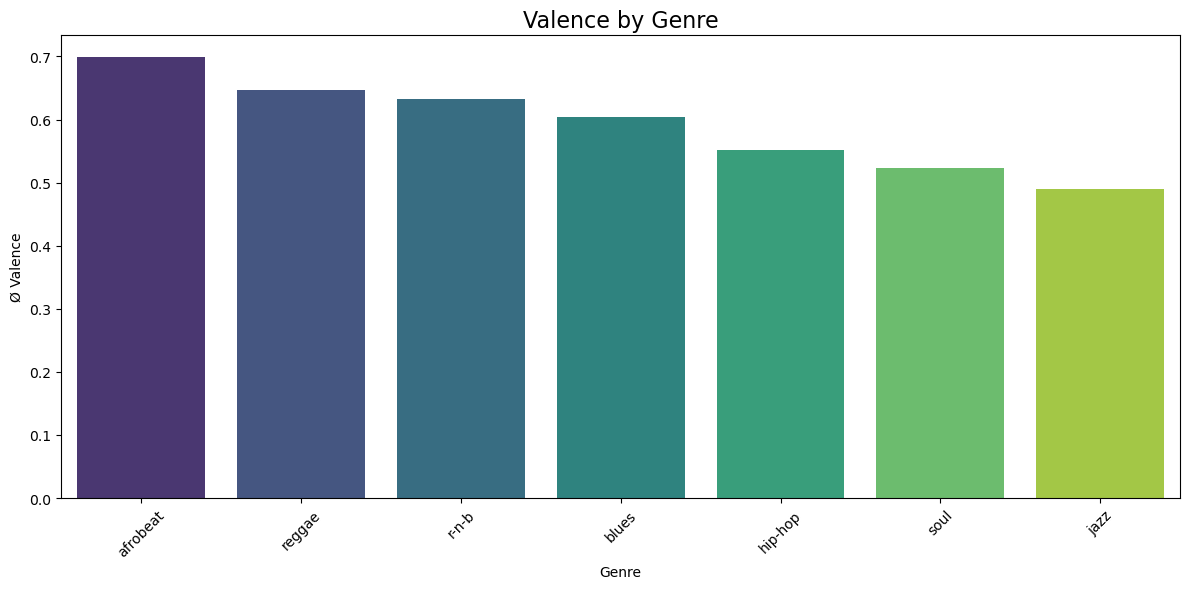

In [10]:
 # Analyse 2: Stimmung (Valence) – Welches Genre klingt am fröhlichsten?
plt.figure(figsize=(12, 6))
genre_dance = df_projekt.groupby('track_genre')['valence'].mean().sort_values(ascending=False)
sns.barplot(x=genre_dance.index, y=genre_dance.values, palette='viridis')
plt.title('Valence by Genre', fontsize=16)
plt.xlabel('Genre')
plt.ylabel('Ø Valence')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_21196\1365206282.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_dance.index, y=genre_dance.values, palette='viridis')


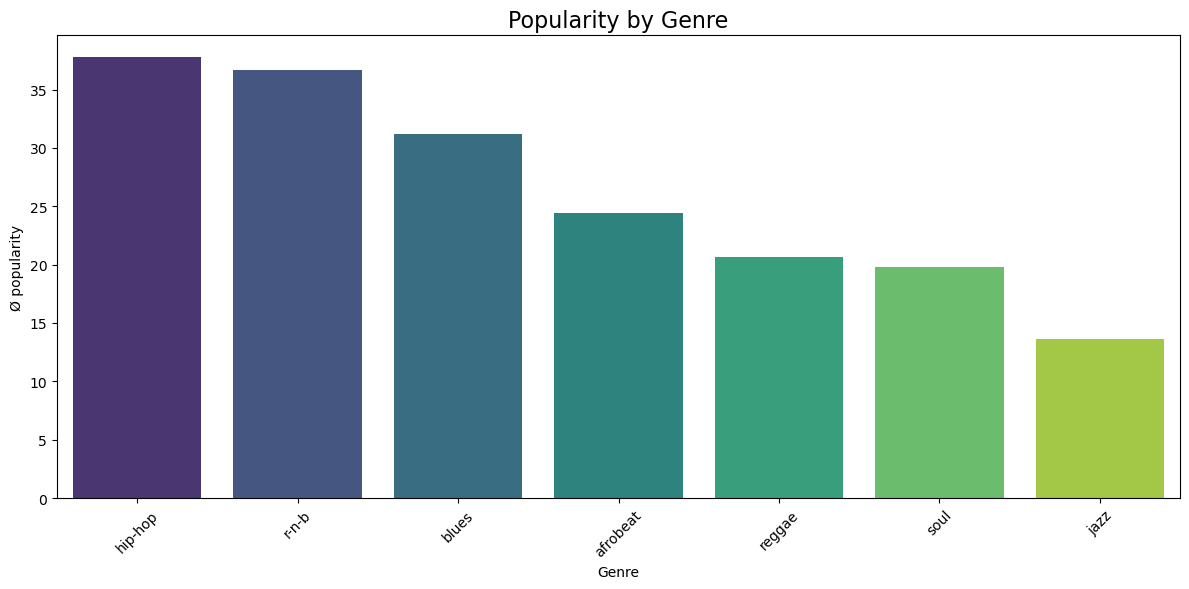

In [11]:
# Analyse 3: Popularität – Wie bekannt sind die Genres auf Spotify?
plt.figure(figsize=(12, 6))
genre_dance = df_projekt.groupby('track_genre')['popularity'].mean().sort_values(ascending=False)
sns.barplot(x=genre_dance.index, y=genre_dance.values, palette='viridis')
plt.title('Popularity by Genre', fontsize=16)
plt.xlabel('Genre')
plt.ylabel('Ø popularity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

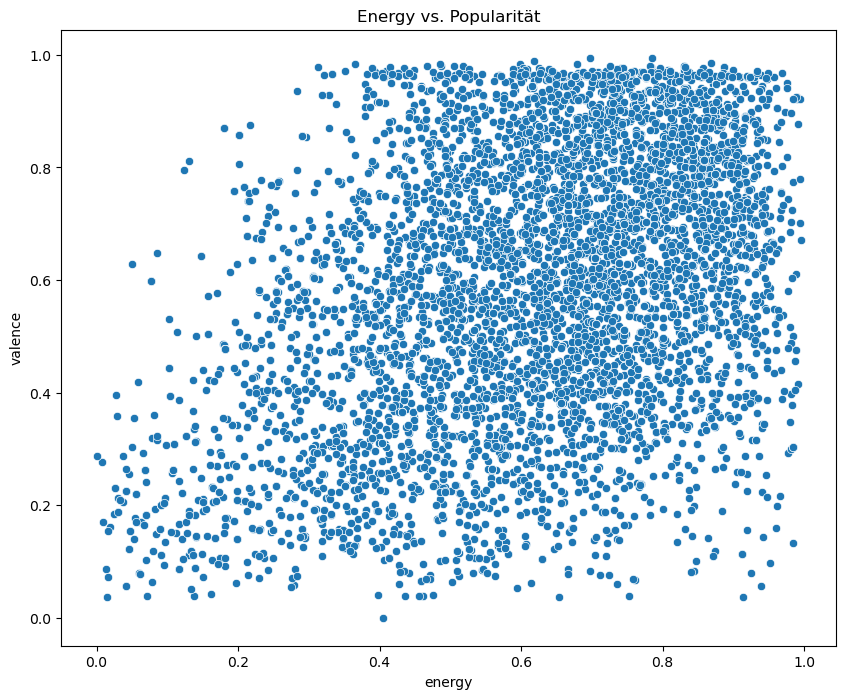

In [14]:
#Energy Scatterplot

plt.figure(figsize=(10,8))
sns.scatterplot(data=df_projekt , x = 'energy', y = 'valence')
plt.title ('Energy vs. Popularität')
plt.show()

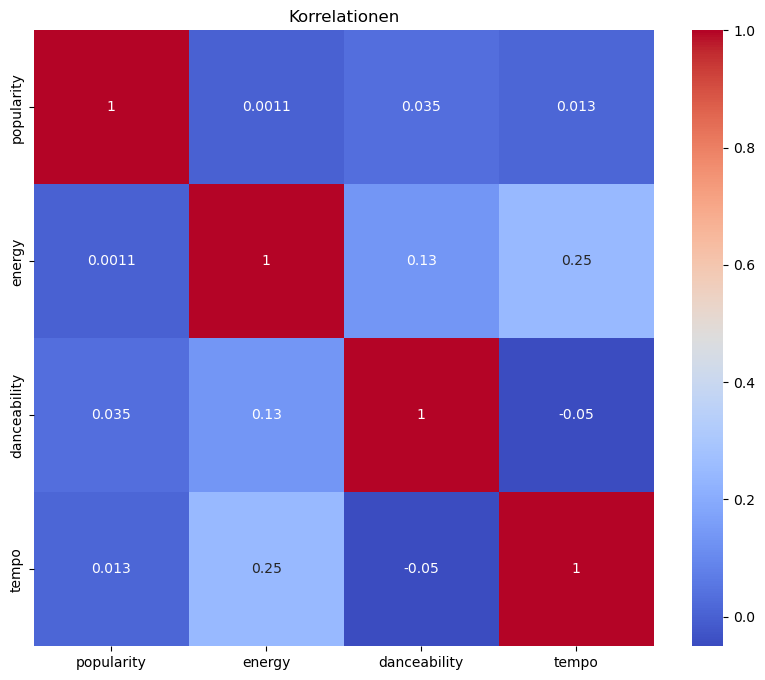

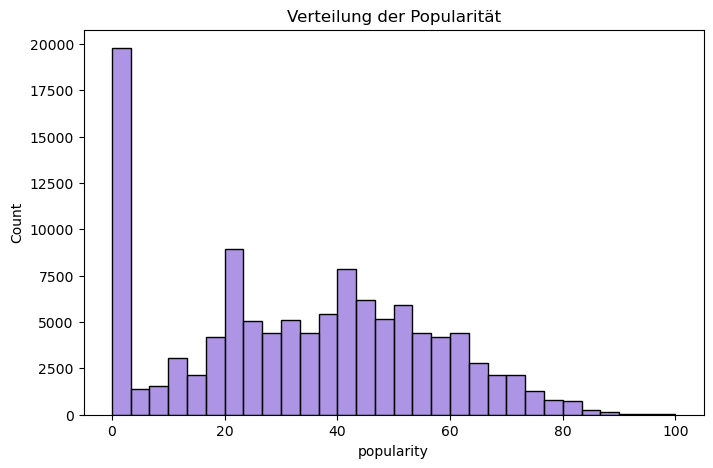

In [13]:

# # Bonus: Korrelation – Hängen Energie, Tempo, Danceability und Popularität zusammen?
plt.figure(figsize=(10, 8))
sns.heatmap(df[['popularity','energy','danceability','tempo']].corr(), 
            annot=True, cmap='coolwarm')
plt.title('Korrelationen')
plt.show()

# # Bonus: Verteilung der Popularität – Wie sind die Songs über Popularität verteilt?
plt.figure(figsize=(8, 5))
sns.histplot(df['popularity'], bins=30, color='mediumpurple')
plt.title('Verteilung der Popularität')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_21196\905439658.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_dance.index, y=genre_dance.values, palette='viridis')


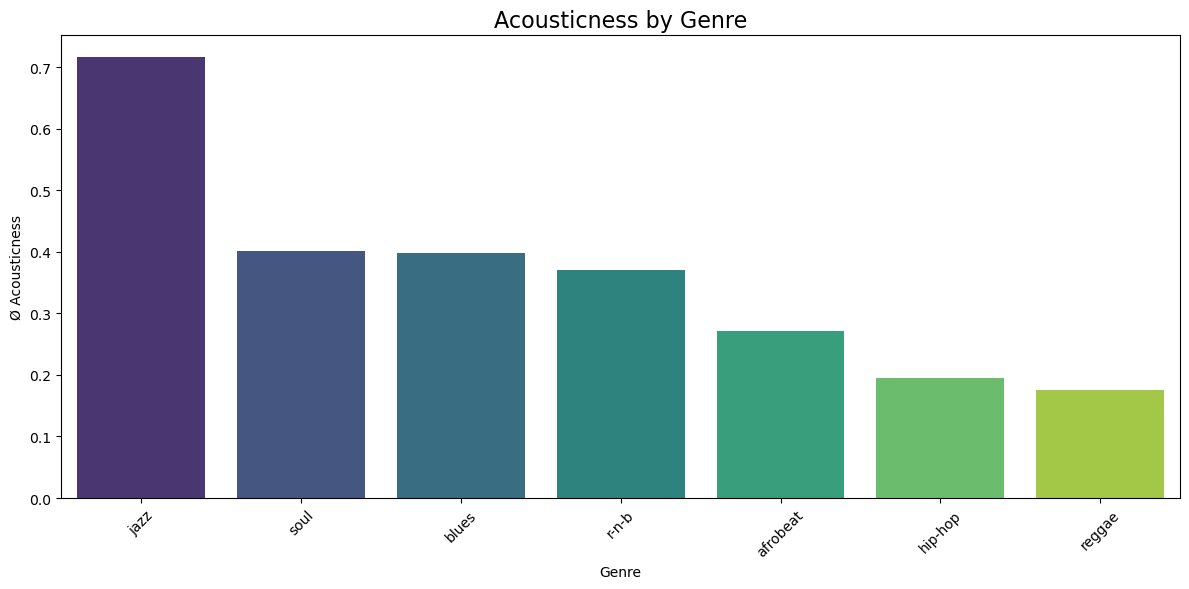

In [15]:
# Analyse 4: Acousticness – Wer benutzt mehr echte Instrumente?
plt.figure(figsize=(12, 6))
genre_dance = df_projekt.groupby('track_genre')['acousticness'].mean().sort_values(ascending=False)
sns.barplot(x=genre_dance.index, y=genre_dance.values, palette='viridis')
plt.title('Acousticness by Genre', fontsize=16)
plt.xlabel('Genre')
plt.ylabel('Ø Acousticness')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_21196\1693020563.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data= df_projekt,


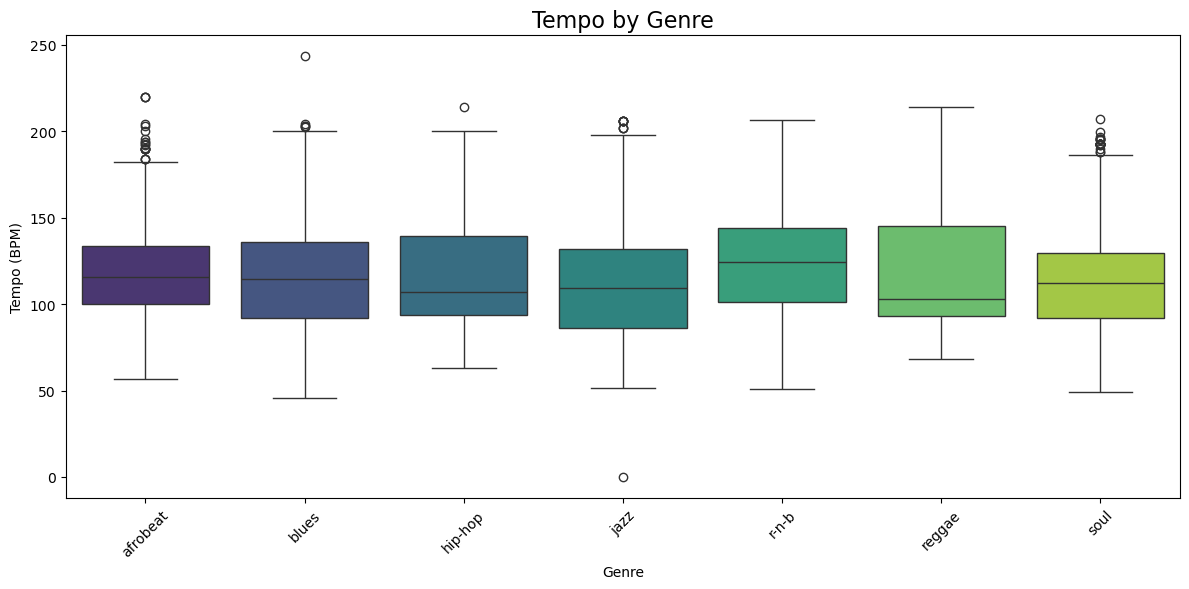

In [17]:
# Analyse 5: Tempo – Wie schnell sind die Genres wirklich?
plt.figure(figsize=(12, 6))
sns.boxplot(data= df_projekt, 
            x='track_genre', 
            y='tempo', 
            palette='viridis')
plt.title('Tempo by Genre', fontsize=16)
plt.xlabel('Genre')
plt.ylabel('Tempo (BPM)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()